In [1]:
import pandas as pd 
import util
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

### Data pre processing 

In [2]:
Re_list = pd.read_csv("data/mock dataset/Re_list.csv", header=None)
Re_list = Re_list[0].to_numpy()
Ivector = pd.read_csv("data/mock dataset/Ivector.csv", header=None)
Ivector = Ivector.to_numpy()
Scvector = pd.read_csv("data/mock dataset/Scvector.csv", header=None)
Scvector = Scvector[0].to_numpy()
Swvector = pd.read_csv("data/mock dataset/Swvector.csv", header=None)
Swvector = Swvector[0].to_numpy()
tvector = pd.read_csv("data/mock dataset/tvector.csv", header=None)
tvector = tvector[0].to_numpy()
t_ww = pd.read_csv("data/mock dataset/t_ww.csv", header=None)
t_ww = t_ww[0].to_numpy()
cases = pd.read_csv("data/mock dataset/cases.csv", header=None)
cases = cases[0].to_numpy()
t_case = pd.read_csv("data/mock dataset//t_cases.csv", header=None)
t_case = t_case[0].to_numpy()
ww = pd.read_csv("data/mock dataset//ww.csv", header=None)
ww = ww[0].to_numpy()

In [4]:
start, end = 13880, 21190
mask_c = (t_case >= start/10) & (t_case <= end/10)
mask_w = (t_ww >= start/10) & (t_ww <= end/10)
cases_in_range = cases[mask_c]
t_case_in_range = t_case[mask_c]
ww_in_range = ww[mask_w]
t_ww_in_range = t_ww[mask_w]
weekly_incidence = util.calculate_weekly_incidence(Scvector[start:end])
sub_t  = tvector[start:end]
weekly_time = sub_t[70::70]
Ivector_mock = Ivector[13880:21190,:]

In [5]:
case_mock = pd.DataFrame({
    'date_c': t_case_in_range,
    'noisy_c_values': cases_in_range
})

ww_mock = pd.DataFrame({
    'date_w': t_ww_in_range,
    'noisy_w_values': ww_in_range
})
case_empt = pd.DataFrame(columns=["date_c", "noisy_c_values"])
ww_empt = pd.DataFrame(columns=["date_w", "noisy_w_values"])
#case_mock.to_csv("data/case_mock.csv", index=False)
#ww_mock.to_csv("data/ww_mock.csv",   index=False)

In [6]:
dt_real = 0.1
epiparams = {
    "n" : 40, # Number of compartments
    "sigma_Re": 0.6,  # Initial standard deviation for Brownian motion
    "lambda_ww": 5000,  # Shedding load scaling constant
    "delta_ww":0.5, # Decay rate of viral load in wastewater
    "cv_ww": 0.1, # CV in wastewater 
    "k_overdispersion_case" : 10, # Overdispersion parameter for weekly incidence 
    "nu": 1/40,  # Transition rate
    "dt": dt_real,  # Time step
    "time_start_day": 1388,  # Start day
    "time_end_day": 2119,  # End day
    "tList": tvector[start:end],  # Time steps
    "rho": 0.1 # Reporting rate 
}
# n= 40
n_particles = 1000
c_i = util.generate_neg_binom(epiparams["n"], 11.528428093645484, 0.8) # Case detection profile
omega_i = util.generate_neg_binom(epiparams["n"], 3.1515151515151514, 0.24444444444444444) # Shedding load profile
f_i= util.generate_neg_binom(epiparams["n"], 3.8989898989898992, 0.4473684210526315) # Infectivity profile 


In [7]:
def get_logL_Joint_prior (Casedata, WWdata, n_particles, epiparams, burnin_point = 0):
    Re_curr = np.random.lognormal(mean=0.0, sigma=0.5, size=(n_particles, 1))
    mu, sigma = 2.5, 1.0
    log10_I_init = np.random.normal(loc=mu, scale=sigma, size=n_particles)
    I_init_total = 10**log10_I_init
    I_curr = np.zeros((n_particles, epiparams["n"]))
    I_curr[:, 0] = I_init_total

    Sc_curr = np.zeros(n_particles)
    Sw_curr = np.zeros(n_particles)

    # Initialize storage for simulation results
    Re, w_list, wmean = [], [], []
    cumulative_incidence_record, wastewater_concentration_record, I_record = [], [], []

    # Determine the number of time points
    n_timepts = len(epiparams["tList"])
    t_day = []              # times when resampling occurs
    
    ancestry = np.empty((n_timepts, n_particles), dtype=int)
    ancestry[:, :] = np.arange(n_particles)  # initial ancestry

    for t_idx in range(n_timepts - 1):
        # Brownian motion update for Re
        dRe = epiparams["sigma_Re"] * np.random.randn(n_particles, 1) * dt_real
        Re_curr = Re_curr + dRe  
        Re_curr = np.clip(Re_curr, 0, 30)
        
        dt = epiparams["tList"][t_idx + 1] - epiparams["tList"][t_idx]
        dI = np.zeros_like(I_curr)
        dSc = np.zeros(n_particles)
        dSw = np.zeros(n_particles)
        # Force of infection
        Psi = epiparams["n"] * epiparams["nu"] * Re_curr.flatten() * (I_curr[:, :epiparams["n"]] @ f_i)
        
        # Infection compartment dynamics
        dI[:, 0] = Psi - epiparams["n"] * epiparams["nu"] * I_curr[:, 0]
        dI[:, 1:epiparams["n"]-1] = -epiparams["n"] * epiparams["nu"] * I_curr[:, 1:epiparams["n"]-1] + epiparams["n"] * epiparams["nu"] * I_curr[:, :epiparams["n"]-2]
        dI[:, epiparams["n"]-1] = epiparams["n"] * epiparams["nu"] * I_curr[:, epiparams["n"]-2]
        
        # Cumulative incidence dynamics
        dSc = epiparams["n"] * epiparams["nu"] * epiparams["rho"] * (I_curr[:, :epiparams["n"]] @ c_i)
        # Wastewater dynamics
        dSw = epiparams["lambda_ww"] * (I_curr[:, :epiparams["n"]] @ omega_i) - epiparams["delta_ww"] * Sw_curr
        
        # Update the state vector using the Euler-Maruyama method
        I_curr[:, :epiparams["n"]] += dI[:, :epiparams["n"]] * dt
        Sc_curr += dSc * dt
        Sw_curr += dSw * dt
        
        # Record simulation results
        cumulative_incidence_record.append(Sc_curr.copy())
        wastewater_concentration_record.append(Sw_curr.copy())
        I_record.append(I_curr.copy())
        Re.append(Re_curr.copy())
        
        date_c_list = Casedata["date_c"].tolist()
        date_w_list = WWdata["date_w"].tolist()
        joint_list = sorted(list(set(date_c_list) | set(date_w_list)))
    
        # Determine the current simulation time for potential observation
        compare_time = epiparams["tList"][t_idx + 1]

        if compare_time in joint_list:
            k_vector = np.arange(n_particles) 
            likelihoods = np.ones(n_particles)

            if compare_time in date_w_list:
                # Retrieve the current wastewater concentration (flatten if needed)
                Sw_curr_flat = np.array(Sw_curr).flatten()
                obsWW = WWdata["noisy_w_values"][WWdata["date_w"] == compare_time]
                # Compute the gamma likelihood for the wastewater data
                likelihoods_ww = stats.gamma.pdf(
                    obsWW,
                    a=(1 / epiparams["cv_ww"]) ** 2,
                    scale=Sw_curr_flat * epiparams["cv_ww"] ** 2
                )
                likelihoods_ww = np.ravel(likelihoods_ww)
                likelihoods *= likelihoods_ww 

            if compare_time in date_c_list:
                # Ensure that we have enough recorded steps (at least 7 days worth)
                steps_back = int(7 / dt_real)
                if len(cumulative_incidence_record) > steps_back:
                    current_idx = len(cumulative_incidence_record) - 1  # current time index
                    week_idx = current_idx - steps_back             # index 7 days ago
                    weekly_incidence = np.zeros(n_particles)
                    
                    # Trace the ancestry for each particle to pick the correct cumulative incidence from 7 days ago
                    for particle in range(n_particles):
                        anc = particle
                        # Trace ancestry from the current time back to week_idx
                        for t in range(current_idx, week_idx, -1):
                            anc = ancestry[t, anc]
                        # Calculate weekly incidence along the same ancestral path
                        weekly_incidence[particle] = cumulative_incidence_record[current_idx][particle] - cumulative_incidence_record[week_idx][anc]
                else:
                    # If not enough time points have been recorded, use the current cumulative incidence
                    weekly_incidence = cumulative_incidence_record[-1]

                # Ensure weekly_incidence is a 1D numpy array of shape (n_particles,)
                weekly_incidence = np.array(weekly_incidence).flatten()
                
                # Retrieve the observed case(s) for this time point
                obsCase = Casedata["noisy_c_values"][Casedata["date_c"] == compare_time]
                
                # Compute likelihoods using the negative binomial PMF
                likelihoods_case = stats.nbinom.pmf(
                    obsCase,
                    epiparams["k_overdispersion_case"],
                    epiparams["k_overdispersion_case"] / (epiparams["k_overdispersion_case"] + weekly_incidence)
                )
                # Ensure likelihoods is a 1D array
                likelihoods_case = np.ravel(likelihoods_case)
                likelihoods *= likelihoods_case 

            if np.isnan(likelihoods).any():
                import pdb; pdb.set_trace()  # or breakpoint()
                print("Warning: NaN values detected in likelihoods!")

            # Resample 
            k_vector = util.resample_particles_multinomial(likelihoods, n_particles)
            ancestry[t_idx + 1, :] = k_vector
            I_curr = I_curr[k_vector, :]
            Sc_curr = Sc_curr[k_vector]
            Sw_curr = Sw_curr[k_vector]
            Re_curr = Re_curr[k_vector]
            t_day.append(compare_time)
            w_list.append(likelihoods)
            wmean.append(np.mean(likelihoods))

    t_day_arr = np.asarray(t_day)
    wmean_arr = np.asarray(wmean)

    keep_mask = t_day_arr >= burnin_point       # True → keep
    safe_w    = np.maximum(wmean_arr[keep_mask],
                           np.finfo(float).tiny)

    theta_logL = np.sum(np.log(safe_w))

    final_particle = np.random.randint(n_particles)
    trajectory_indices = [final_particle]
    for t in range(n_timepts - 1, 0, -1):
        final_particle = ancestry[t, final_particle]
        trajectory_indices.insert(0, final_particle)
    
    recon = {
        "Re": np.array([Re[t][trajectory_indices[t]] for t in range(len(Re))]),
        "t_day": np.array(t_day),
        "t": epiparams["tList"][1:],
        "I_record": np.array([I_record[t][trajectory_indices[t], :] for t in range(len(I_record))]),
        "Cumulative": np.array([cumulative_incidence_record[t][trajectory_indices[t]] for t in range(len(cumulative_incidence_record))]),
        "WW_concentration": np.array([wastewater_concentration_record[t][trajectory_indices[t]] for t in range(len(wastewater_concentration_record))]),
        "I_init_vals":     I_init_total, 
        "first_parents":   np.unique(ancestry[1389, :]),
        "ancestry": ancestry
    
    }

    w_incidence = util.calculate_weekly_incidence(recon["Cumulative"])
    sub_t  = np.arange(0, 140, dt_real)
    weekly_time = sub_t[70::70]
    recon["w_incidence"] = w_incidence
    recon["weekly_time"] = weekly_time
    d_incidence = util.calculate_daily_incidence(recon["Cumulative"])
    recon["d_incidence"] = d_incidence
    recon["daily_time"] = weekly_time = sub_t[10::10]
    recon["ess_values"] = [len(np.unique(ancestry[t, :])) for t in range(n_timepts)]
    recon["wmean"] = np.asarray(wmean)
    return theta_logL, recon

### Figure 4: Mock case dataset 

In [ ]:
rho_value = [0.10, 0.14, 0.18, 0.22, 0.26, 0.30, 0.34, 0.38, 0.42, 0.46, 0.50, 0.54, 0.58, 0.62, 0.66, 0.70, 0.74, 0.78, 0.82, 0.86, 0.90, 0.94, 0.95]
sigma_Re_value = [
  0.10,
  0.20, 0.22, 0.24, 0.26, 0.28, 0.30, 0.32, 0.34, 0.36, 0.38,
  0.40, 0.42, 0.44, 0.46, 0.48, 0.50, 0.52, 0.54, 0.56, 0.58,
  0.60, 0.62, 0.64, 0.66, 0.68, 0.70, 0.72, 0.74, 0.76, 0.78,
  0.80, 0.82, 0.84, 0.86, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98, 1.00,
  1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45, 1.50,
  1.55, 1.60         
]

mean_ll_array_j = np.zeros((len(rho_value ), len(sigma_Re_value)))
n_replicates = 10

# Loop over the grid of (rho, sigma_Re) values
for i, rho in enumerate(rho_value):
    for j, sigma in enumerate(sigma_Re_value):
        log_likelihoods = []
        for _ in range(n_replicates):
            epiparams["rho"] = rho
            epiparams["sigma_Re"] = sigma
            # Run your log-likelihood function (replace with your actual function)
            theta_logL, recon = get_logL_Joint_prior(case_mock, ww_empt, n_particles, epiparams, burnin_point=1460)
            log_likelihoods.append(theta_logL)
        # Store the mean log-likelihood in the 2D array
        mean_ll_array_j[i, j] = np.mean(log_likelihoods)

#np.save("mean_ll_array_case_burnin.npy", mean_ll_array_j)


In [8]:
# Case only 
mean_ll_array_j = np.load("mock_results/mean_ll_array_case_burnin.npy")
mean_ll_array_replot = mean_ll_array_j.copy()
mean_ll_array_replot[mean_ll_array_replot < -410] = -410

rho_value = [0.10, 0.14, 0.18, 0.22, 0.26, 0.30, 0.34, 0.38, 0.42, 0.46, 0.50, 0.54, 0.58, 0.62, 0.66, 0.70, 0.74, 0.78, 0.82, 0.86, 0.90, 0.94, 0.95]
sigma_Re_value = [
  0.10,
  0.20, 0.22, 0.24, 0.26, 0.28, 0.30, 0.32, 0.34, 0.36, 0.38,
  0.40, 0.42, 0.44, 0.46, 0.48, 0.50, 0.52, 0.54, 0.56, 0.58,
  0.60, 0.62, 0.64, 0.66, 0.68, 0.70, 0.72, 0.74, 0.76, 0.78,
  0.80, 0.82, 0.84, 0.86, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98, 
  1.00, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45, 
  1.50, 1.55, 1.60         
]

recon_dict_case = {}

combinations = [
    (0.2, 0.66),  # combination 1
    (0.8, 0.66)   # combination 2
]

for (this_rho, this_sigma) in combinations:
    epiparams["rho"] = this_rho
    epiparams["sigma_Re"] = this_sigma
    theta_logL, recon = get_logL_Joint_prior(case_mock, ww_empt, n_particles, epiparams)
    recon_dict_case[(this_rho, this_sigma)] = recon

In [9]:
rho_fixed = 0.2
sigma_EF     = [0.2, 1.5]

recon_dict_ww_EF_case = {}

for this_sigma in sigma_EF:
    epiparams["rho"] = rho_fixed
    epiparams["sigma_Re"]  = this_sigma

    theta_logL, recon = get_logL_Joint_prior(
        case_mock, ww_empt, n_particles, epiparams, burnin_point=1460
    )
    recon_dict_ww_EF_case[this_sigma] = recon

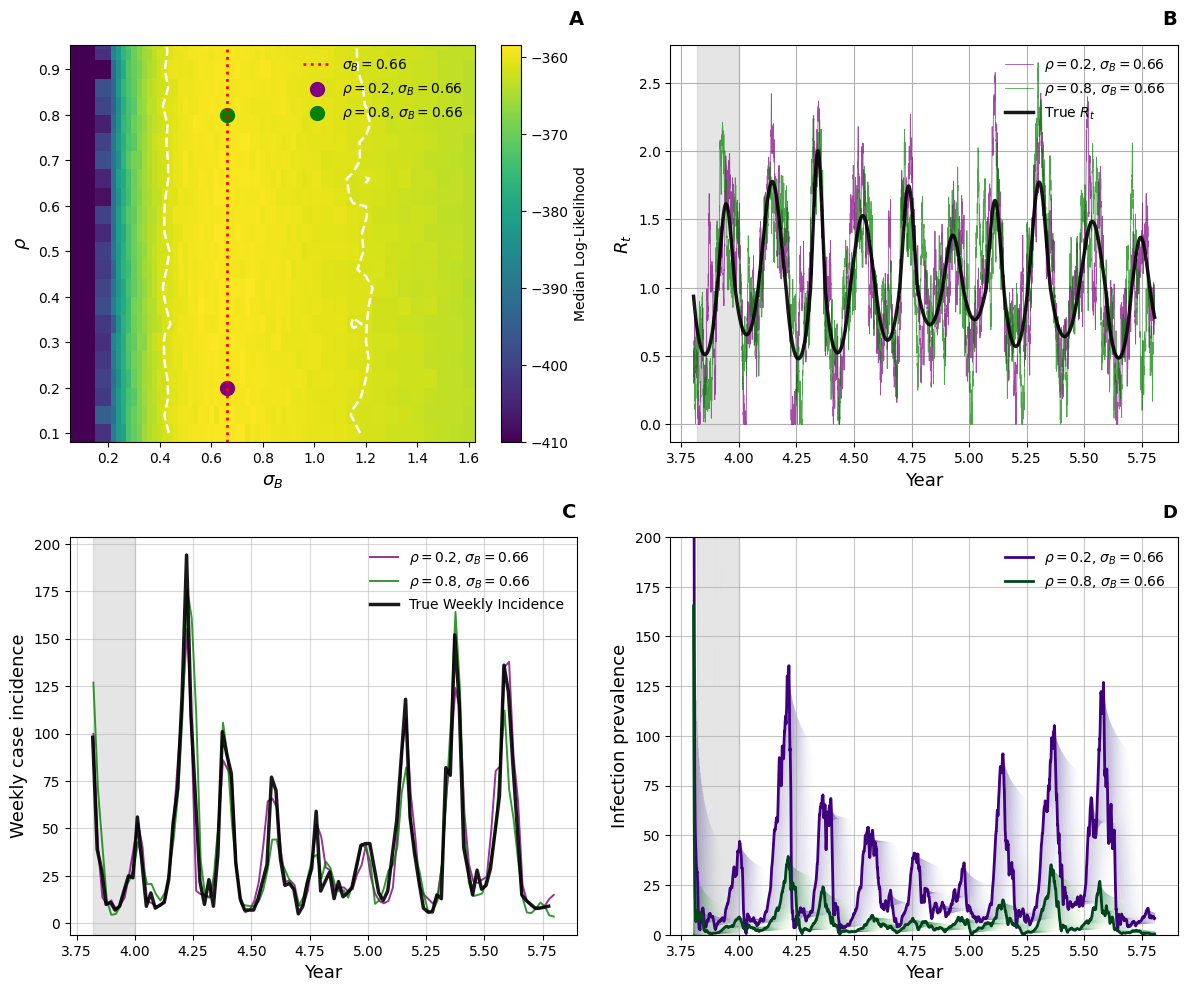

In [10]:
# Fig 4
label_font = {'fontsize': 13}
color_map = {(0.2, 0.66): 'purple',
             (0.8, 0.66): 'green'}

Lmax         = mean_ll_array_replot.max()
threshold = Lmax - 2.996

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# ========= Panel A – log‑likelihood heat‑map =========
ax = axs[0, 0]
sigmaGrid, RhoGrid = np.meshgrid(sigma_Re_value, rho_value)
heat = ax.pcolormesh(sigmaGrid, RhoGrid, mean_ll_array_replot,
                     cmap="viridis", shading="auto")
plt.colorbar(heat, ax=ax, label="Median Log‑Likelihood")

# Mark the MLE σ value with a vertical red dashed line
i_max, j_max = np.unravel_index(np.argmax(mean_ll_array_j),
                                mean_ll_array_j.shape)
mle_sigma = sigma_Re_value[j_max]
ax.axvline(mle_sigma, color="red", linestyle=":", linewidth=2,
           label=fr"$σ_{{B}}$ = {mle_sigma:.3g}")

# Add purple / green dots for the two (ρ, σ_Re) settings
for (rho, sig), col in color_map.items():
    ax.scatter(sig, rho, color=col, s=100, marker='o',
               label=fr"$\rho={rho}$, $\sigma_{{B}}={sig}$")
# 95 % confidence contour
cs = ax.contour(sigmaGrid, RhoGrid, mean_ll_array_replot,
                 levels=[threshold], colors="white", linestyles="--",
                 linewidths=1.8)

ax.set_xlabel(r"$\sigma_{B}$", **label_font)
ax.set_ylabel(r"$\rho$", **label_font)
ax.text(1.23, 1.05, 'A', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0)


# ========== Panel B: Reconstructed R_t ==========
ax = axs[0, 1]
for (this_rho, this_lambda), recon in recon_dict_case.items():
    ax.plot(recon["t"]/365, recon["Re"], 
            color=color_map[(this_rho, this_lambda)], 
            alpha=0.7, linewidth=0.6,
            label=r"$\rho={}$, $\sigma_{{B}}={}$".format(this_rho, this_lambda))
# Plot the mock/true R_t in red
ax.plot(tvector[start:end]/365, Re_list[start:end],
        linestyle='-', color='black', alpha=0.9, linewidth=2.5, label=r'True $R_t$')
ax.axvspan(1394/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("$R_t$", **label_font)
ax.grid(True)
ax.legend(loc='upper right', framealpha=0)
ax.text(0.97, 1.05, 'B', transform=ax.transAxes, fontsize=14, fontweight='bold')


# ========= Panel C – reconstructed weekly *incidence* =========
ax = axs[1, 0]
for (rho, sig), recon in recon_dict_case.items():
    incidence = recon["w_incidence"] # / rho
    ax.plot(weekly_time/365, incidence, color=color_map[(rho, sig)],
            linewidth=1.4, alpha=0.8,
            label=fr"$\rho={rho}$, $\sigma_{{B}}={sig}$")
# Plot the mock/true weekly incidence in red
ax.plot(case_mock['date_c']/365, case_mock['noisy_c_values'],
        linestyle='-', color='black', alpha=0.9, linewidth=2.5, label="True Weekly Incidence")
ax.axvspan(1394/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("Weekly case incidence", **label_font)
ax.text(0.97, 1.05, 'C', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.5)
ax.legend(loc='upper right', framealpha=0)

# -------------------------------------------------------------
# Panel D – prevalence: grayscale vs purple-white
# -------------------------------------------------------------
ax = axs[1, 1]

# Which (ρ, σ) pairs to compare
combos = [(0.2, 0.66),   # → grayscale
          (0.8, 0.66)]   # → purple-white

k               = next(iter(recon_dict_case.values()))['I_record'].shape[1]
colors_purple   = [plt.cm.Purples_r(i/(k-1)) for i in range(k)]   # purple → white
colors_green    = [plt.cm.Greens_r(i/(k-1))  for i in range(k)]   # green  → white
combo_cmaps     = {combos[0]: colors_purple,   # first tuple  → purple ramp
                   combos[1]: colors_green}    # second tuple → green  ramp


handles, labels = [], []        # custom legend

for (rho, sig) in combos:
    recon   = recon_dict_case[(rho, sig)]
    I_rec   = np.asarray(recon["I_record"])
    t_year  = recon["t"] / 365
    colors  = combo_cmaps[(rho, sig)]

    alpha_body = 0.25            # very light, so the outline stands out
    for i in reversed(range(k)):
        ax.plot(t_year, I_rec[:, i],
                color=colors[i],
                linewidth=0.4, alpha=alpha_body, zorder=1)

    first_compartment = I_rec[:, 0] 
    outline_color = colors[0]            # darkest colour in the ramp
    h, = ax.plot(t_year, first_compartment,
                 color=outline_color,
                 linewidth=2.0, zorder=2)
    handles.append(h)
    labels.append(fr"$\rho={rho}$, $\sigma_{{B}}={sig}$")

# ---- cosmetics ---------------------------------------------------------
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("Infection prevalence", **label_font)
ax.text(0.97, 1.05, 'D', transform=ax.transAxes,
        **label_font, fontweight='bold')      # ← same fontdict as others
ax.grid(True, alpha=0.7)
ax.set_ylim(0, 200)
ax.axvspan(1394/365, 1460/365, color='grey', alpha=0.2)

ax.legend(handles, labels, loc="upper right", frameon=False)


plt.tight_layout()
plt.show()

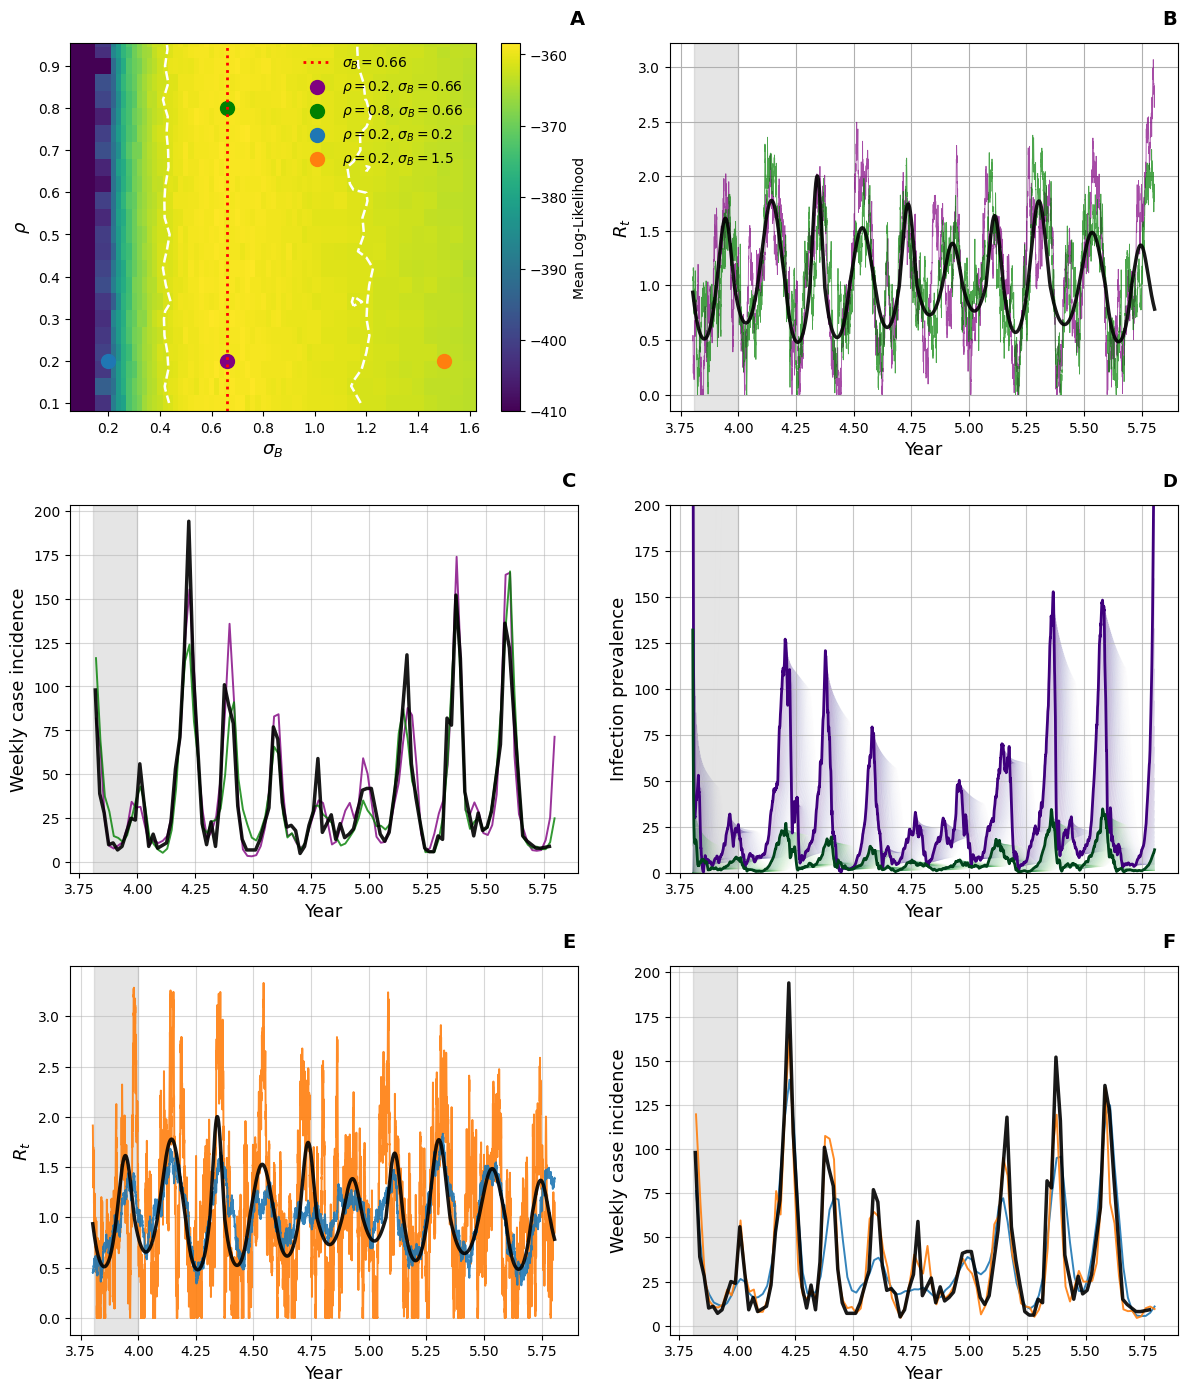

In [11]:
# Fig 4
label_font = {'fontsize': 13}
color_map = {
    # main comparisons (Panels A–D)
    (0.2, 0.66): "purple",
    (0.8, 0.66): "green",
    (rho_fixed, 0.2): "tab:blue",
    (rho_fixed, 1.5): "tab:orange",
}

fig, axs = plt.subplots(3, 2, figsize=(12, 14))


# ========= Panel A – log‑likelihood heat‑map =========
ax = axs[0, 0]
sigmaGrid, RhoGrid = np.meshgrid(sigma_Re_value, rho_value)
heat = ax.pcolormesh(sigmaGrid, RhoGrid, mean_ll_array_replot,
                     cmap="viridis", shading="auto")
plt.colorbar(heat, ax=ax, label="Mean Log‑Likelihood")

# Mark the MLE σ value with a vertical red dashed line
i_max, j_max = np.unravel_index(np.argmax(mean_ll_array_j),
                                mean_ll_array_j.shape)
mle_sigma = sigma_Re_value[j_max]
ax.axvline(mle_sigma, color="red", linestyle=":", linewidth=2,
           label=fr"$σ_{{B}}$ = {mle_sigma:.3g}")

# Add purple / green dots for the two (ρ, σ_Re) settings
for (rho, sig), col in color_map.items():
    ax.scatter(sig, rho, color=col, s=100, marker='o',
               label=fr"$\rho={rho}$, $\sigma_{{B}}={sig}$")
# 95 % confidence contour
cs = ax.contour(sigmaGrid, RhoGrid, mean_ll_array_replot,
                 levels=[threshold], colors="white", linestyles="--",
                 linewidths=1.8)

ax.set_xlabel(r"$\sigma_{B}$", **label_font)
ax.set_ylabel(r"$\rho$", **label_font)
ax.text(1.23, 1.05, 'A', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0)


# ========== Panel B: Reconstructed R_t ==========
ax = axs[0, 1]
for (this_rho, this_lambda), recon in recon_dict_case.items():
    ax.plot(recon["t"]/365, recon["Re"], 
            color=color_map[(this_rho, this_lambda)], 
            alpha=0.7, linewidth=0.6,
            label=r"$\rho={}$, $\sigma_{{B}}={}$".format(this_rho, this_lambda))
# Plot the mock/true R_t in red
ax.plot(tvector[start:end]/365, Re_list[start:end],
        linestyle='-', color='black', alpha=0.9, linewidth=2.5, label=r'True $R_t$')
ax.axvspan(1390/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("$R_t$", **label_font)
ax.grid(True)
# ax.legend(loc='upper right', framealpha=0)
ax.text(0.97, 1.05, 'B', transform=ax.transAxes, fontsize=14, fontweight='bold')


# ========= Panel C – reconstructed weekly *incidence* =========
ax = axs[1, 0]
for (rho, sig), recon in recon_dict_case.items():
    incidence = recon["w_incidence"] # / rho
    ax.plot(weekly_time/365, incidence, color=color_map[(rho, sig)],
            linewidth=1.4, alpha=0.8,
            label=fr"$\rho={rho}$, $\sigma_{{B}}={sig}$")
# Plot the mock/true weekly incidence in red
ax.plot(case_mock['date_c']/365, case_mock['noisy_c_values'],
        linestyle='-', color='black', alpha=0.9, linewidth=2.5, label="True Weekly Incidence")
ax.axvspan(1390/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("Weekly case incidence", **label_font)
ax.text(0.97, 1.05, 'C', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.5)
# ax.legend(loc='upper right', framealpha=0)

# -------------------------------------------------------------
# Panel D – prevalence: grayscale vs purple-white
# -------------------------------------------------------------
ax = axs[1, 1]

# Which (ρ, σ) pairs to compare
combos = [(0.2, 0.66),   # → grayscale
          (0.8, 0.66)]   # → purple-white

k               = next(iter(recon_dict_case.values()))['I_record'].shape[1]
colors_purple   = [plt.cm.Purples_r(i/(k-1)) for i in range(k)]   # purple → white
colors_green    = [plt.cm.Greens_r(i/(k-1))  for i in range(k)]   # green  → white
combo_cmaps     = {combos[0]: colors_purple,   # first tuple  → purple ramp
                   combos[1]: colors_green}    # second tuple → green  ramp


handles, labels = [], []        # custom legend

for (rho, sig) in combos:
    recon   = recon_dict_case[(rho, sig)]
    I_rec   = np.asarray(recon["I_record"])
    t_year  = recon["t"] / 365
    colors  = combo_cmaps[(rho, sig)]

    alpha_body = 0.25            # very light, so the outline stands out
    for i in reversed(range(k)):
        ax.plot(t_year, I_rec[:, i],
                color=colors[i],
                linewidth=0.4, alpha=alpha_body, zorder=1)

    first_compartment = I_rec[:, 0] 
    outline_color = colors[0]            # darkest colour in the ramp
    h, = ax.plot(t_year, first_compartment,
                 color=outline_color,
                 linewidth=2.0, zorder=2)
    handles.append(h)
    labels.append(fr"$\rho={rho}$, $\sigma_{{B}}={sig}$")
ax.axvspan(1390/365, 1460/365, color='grey', alpha=0.2)
# ---- cosmetics ---------------------------------------------------------
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("Infection prevalence", **label_font)
ax.text(0.97, 1.05, 'D', transform=ax.transAxes,
        **label_font, fontweight='bold')      # ← same fontdict as others
ax.grid(True, alpha=0.7)
ax.set_ylim(0, 200)
# ax.legend(handles, labels, loc="upper right", frameon=False)


# ========= Panel E – reconstructed Rt (rho fixed, sigma_B = 0.2 and 1.5) =========
ax = axs[2, 0]

for sig, col in [(1.5, "tab:orange"),(0.2, "tab:blue")]:
    recon = recon_dict_ww_EF_case[sig]
    ax.plot(recon["t"]/365, recon["Re"],
            color=col, alpha=0.9, linewidth=1.4,
            label=fr"$\rho={rho_fixed},\ \sigma_B={sig}$")

# True Rt
ax.plot(tvector[start:end]/365, Re_list[start:end],
        color="black", alpha=0.9, linewidth=2.5, label=r"True $R_t$")
ax.axvspan(1390/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel(r"$R_t$", **label_font)
ax.grid(True, alpha=0.5)
ax.text(0.97, 1.05, "E", transform=ax.transAxes,
        fontsize=14, fontweight="bold")
# ax.legend(loc="upper right", framealpha=0)


# ========= Panel F – reconstructed weekly incidence (rho fixed, sigma_B = 0.2 and 1.5) =========
ax = axs[2, 1]

for sig, col in [(0.2, "tab:blue"), (1.5, "tab:orange")]:
    recon = recon_dict_ww_EF_case[sig]
    incidence = recon["w_incidence"]  # keep same definition as Panel C
    ax.plot(weekly_time/365, incidence,
            color=col, alpha=0.9, linewidth=1.4,
            label=fr"$\rho={rho_fixed},\ \sigma_B={sig}$")

# True weekly incidence
ax.plot(case_mock['date_c']/365, case_mock['noisy_c_values'],
        linestyle='-', color='black', alpha=0.9, linewidth=2.5,
        label="True Weekly Incidence")
ax.axvspan(1390/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("Weekly case incidence", **label_font)
ax.grid(True, alpha=0.5)
ax.text(0.97, 1.05, "F", transform=ax.transAxes,
        fontsize=14, fontweight="bold")
# ax.legend(loc="upper right", framealpha=0)



plt.tight_layout()
plt.show()

In [12]:
# Case alternative
median_ll_array_j = np.load("mock_results/median_ll_array_case.npy")
median_ll_array_replot = median_ll_array_j.copy()
median_ll_array_replot[median_ll_array_replot < -410] = -410
median_ll_array_replot = median_ll_array_replot.T
sigma_Re_value = [round(x, 2) for x in [i * 0.02 + 0.01 for i in range(int((1.6 - 0.01) / 0.02) + 1)]]
rho_value = [round(x, 2) for x in [i * 0.04 + 0.10 for i in range(int((0.95 - 0.10) / 0.04) + 1)]]

recon_dict_case = {}

combinations = [
    (0.2, 0.69),  # combination 1
    (0.8, 0.69)   # combination 2
]

for (this_rho, this_sigma) in combinations:
    epiparams["rho"] = this_rho
    epiparams["sigma_Re"] = this_sigma
    theta_logL, recon = get_logL_Joint_prior(case_mock, ww_empt, n_particles, epiparams)
    recon_dict_case[(this_rho, this_sigma)] = recon

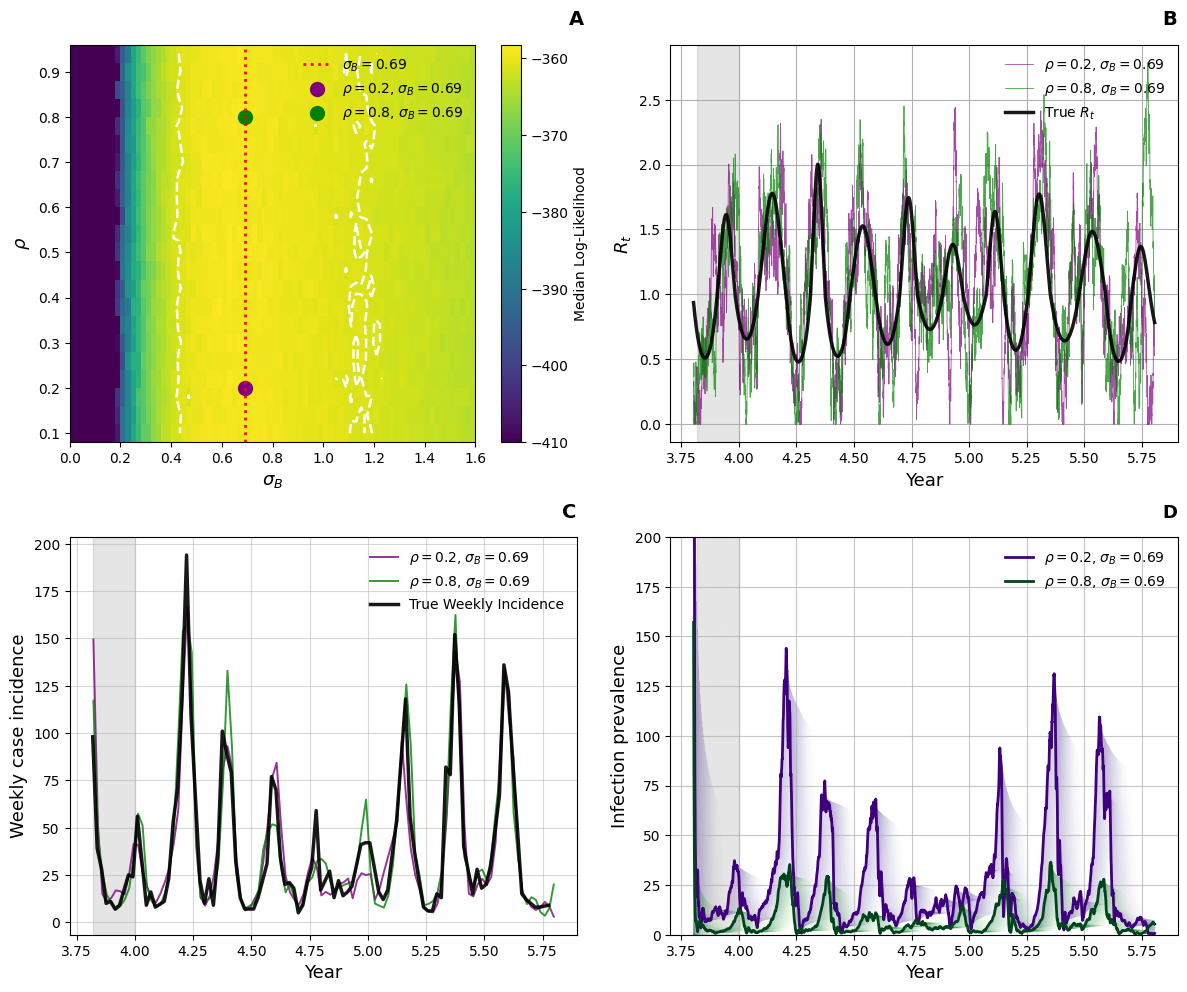

In [13]:
# Fig 4
label_font = {'fontsize': 13}
color_map = {(0.2, 0.69): 'purple',
             (0.8, 0.69): 'green'}

Lmax         = median_ll_array_replot.max()
threshold = Lmax - 2.996

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# ========= Panel A – log‑likelihood heat‑map =========
ax = axs[0, 0]
sigmaGrid, rhoGrid = np.meshgrid(sigma_Re_value, rho_value)
heat = ax.pcolormesh(sigmaGrid, rhoGrid, median_ll_array_replot,
                     cmap="viridis", shading="auto")
plt.colorbar(heat, ax=ax, label="Median Log‑Likelihood")

# Mark the MLE σ value with a vertical red dashed line
i_max, j_max = np.unravel_index(np.argmax(median_ll_array_replot),
                                median_ll_array_replot.shape)
mle_sigma = sigma_Re_value[j_max]
ax.axvline(mle_sigma, color="red", linestyle=":", linewidth=2,
           label=fr"$σ_{{B}}$ = {mle_sigma:.3g}")

# Add purple / green dots for the two (ρ, σ_Re) settings
for (rho, sig), col in color_map.items():
    ax.scatter(sig, rho, color=col, s=100, marker='o',
               label=fr"$\rho={rho}$, $\sigma_{{B}}={sig}$")
# 95 % confidence contour
cs = ax.contour(sigmaGrid, rhoGrid, median_ll_array_replot,
                 levels=[threshold], colors="white", linestyles="--",
                 linewidths=1.8)

ax.set_xlabel(r"$\sigma_{B}$", **label_font)
ax.set_ylabel(r"$\rho$", **label_font)
ax.text(1.23, 1.05, 'A', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0)


# ========== Panel B: Reconstructed R_t ==========
ax = axs[0, 1]
for (this_rho, this_lambda), recon in recon_dict_case.items():
    ax.plot(recon["t"]/365, recon["Re"], 
            color=color_map[(this_rho, this_lambda)], 
            alpha=0.7, linewidth=0.6,
            label=r"$\rho={}$, $\sigma_{{B}}={}$".format(this_rho, this_lambda))
# Plot the mock/true R_t in red
ax.plot(tvector[start:end]/365, Re_list[start:end],
        linestyle='-', color='black', alpha=0.9, linewidth=2.5, label=r'True $R_t$')
ax.axvspan(1394/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("$R_t$", **label_font)
ax.grid(True)
ax.legend(loc='upper right', framealpha=0)
ax.text(0.97, 1.05, 'B', transform=ax.transAxes, fontsize=14, fontweight='bold')


# ========= Panel C – reconstructed weekly *incidence* =========
ax = axs[1, 0]
for (rho, sig), recon in recon_dict_case.items():
    incidence = recon["w_incidence"] # / rho
    ax.plot(weekly_time/365, incidence, color=color_map[(rho, sig)],
            linewidth=1.4, alpha=0.8,
            label=fr"$\rho={rho}$, $\sigma_{{B}}={sig}$")
# Plot the mock/true weekly incidence in red
ax.plot(case_mock['date_c']/365, case_mock['noisy_c_values'],
        linestyle='-', color='black', alpha=0.9, linewidth=2.5, label="True Weekly Incidence")
ax.axvspan(1394/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("Weekly case incidence", **label_font)
ax.text(0.97, 1.05, 'C', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.5)
ax.legend(loc='upper right', framealpha=0)

# -------------------------------------------------------------
# Panel D – prevalence: grayscale vs purple-white
# -------------------------------------------------------------
ax = axs[1, 1]

# Which (ρ, σ) pairs to compare
combos = [(0.2, 0.69),   # → grayscale
          (0.8, 0.69)]   # → purple-white

k               = next(iter(recon_dict_case.values()))['I_record'].shape[1]
colors_purple   = [plt.cm.Purples_r(i/(k-1)) for i in range(k)]   # purple → white
colors_green    = [plt.cm.Greens_r(i/(k-1))  for i in range(k)]   # green  → white
combo_cmaps     = {combos[0]: colors_purple,   # first tuple  → purple ramp
                   combos[1]: colors_green}    # second tuple → green  ramp


handles, labels = [], []        # custom legend

for (rho, sig) in combos:
    recon   = recon_dict_case[(rho, sig)]
    I_rec   = np.asarray(recon["I_record"])
    t_year  = recon["t"] / 365
    colors  = combo_cmaps[(rho, sig)]

    alpha_body = 0.25            # very light, so the outline stands out
    for i in reversed(range(k)):
        ax.plot(t_year, I_rec[:, i],
                color=colors[i],
                linewidth=0.4, alpha=alpha_body, zorder=1)

    first_compartment = I_rec[:, 0] 
    outline_color = colors[0]            # darkest colour in the ramp
    h, = ax.plot(t_year, first_compartment,
                 color=outline_color,
                 linewidth=2.0, zorder=2)
    handles.append(h)
    labels.append(fr"$\rho={rho}$, $\sigma_{{B}}={sig}$")

# ---- cosmetics ---------------------------------------------------------
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("Infection prevalence", **label_font)
ax.text(0.97, 1.05, 'D', transform=ax.transAxes,
        **label_font, fontweight='bold')      # ← same fontdict as others
ax.grid(True, alpha=0.7)
ax.set_ylim(0, 200)
ax.axvspan(1394/365, 1460/365, color='grey', alpha=0.2)

ax.legend(handles, labels, loc="upper right", frameon=False)


plt.tight_layout()
plt.show()

### Figure 5: Mock wastewater dataset 

In [ ]:
# WW only
sigma_Re_value = np.round(np.arange(0.0, 1.5 + 0.0001, 0.05), 3).tolist()
lambda_value = list(range(6000, 16000 + 1, 300))

n_repl    = 10               
logL_all  = np.empty((len(lambda_value), len(sigma_Re_value), n_repl))
mean_ll_array_ww = np.empty((len(lambda_value), len(sigma_Re_value)))  

for i, lambd in enumerate(lambda_value):
    epiparams["lambda_ww"] = lambd

    for j, sigma in enumerate(sigma_Re_value):
        epiparams["sigma_Re"] = sigma

        for r in range(n_repl):
            theta_logL, recon = get_logL_Joint_prior(
                case_empt, ww_mock, n_particles, epiparams, burnin_point=1460
            )
            logL_all[i, j, r] = theta_logL     

        mean_ll_array_ww[i, j] = logL_all[i, j].mean()

# np.save("mock_results/logL_all_ww_burnin_10.npy", logL_all)

In [21]:
logL_all = np.load("mock_results/logL_all_ww_burnin_10.npy")
n_repl    = 10    
median_ll_array_ww_replot = util.analyze_median(logL_all, lambda_value, sigma_Re_value)
median_ll_array_ww_replot[median_ll_array_ww_replot < -2650] = -2650

In [23]:
sigma_Re_value = np.round(np.arange(0.0, 1.5 + 0.0001, 0.05), 3).tolist()
lambda_value = list(range(6000, 16000 + 1, 300))
# logL_all = np.load("mock_results/logL_all_ww_burnin.npy")
logL_all = np.load("mock_results/logL_all_ww_burnin_10.npy")
n_repl    = 10    
median_ll_array_ww_replot = util.analyze_median(logL_all, lambda_value, sigma_Re_value)


#median_ll_array_ww = np.load("mock_results/median_ll_array_ww.npy")
#median_ll_array_ww_replot= median_ll_array_ww.T
#sigma_Re_value = [round(x, 2) for x in [i * 0.02 + 0.01 for i in range(int((1.6 - 0.01) / 0.02) + 1)]]
#lambda_value = list(range(6000, 16000 + 1, 300))

median_ll_array_ww_replot[median_ll_array_ww_replot < -2650] = -2650


In [24]:
recon_dict_ww = {}

combinations = [
    (8000, 0.56),  # combination 1
    (14000, 0.56)   # combination 2
]
for (this_lambda, this_sigma) in combinations:
    epiparams["lambda_ww"] = this_lambda
    epiparams["sigma_Re"] = this_sigma
    theta_logL, recon = get_logL_Joint_prior(case_empt, ww_mock, n_particles, epiparams,burnin_point=1460)
    recon_dict_ww[(this_lambda, this_sigma)] = recon

In [19]:
lambda_fixed = 8000
sigma_EF     = [0.2, 1.5]

recon_dict_ww_EF = {}

for this_sigma in sigma_EF:
    epiparams["lambda_ww"] = lambda_fixed
    epiparams["sigma_Re"]  = this_sigma

    theta_logL, recon = get_logL_Joint_prior(
        case_empt, ww_mock, n_particles, epiparams, burnin_point=1460
    )
    recon_dict_ww_EF[this_sigma] = recon

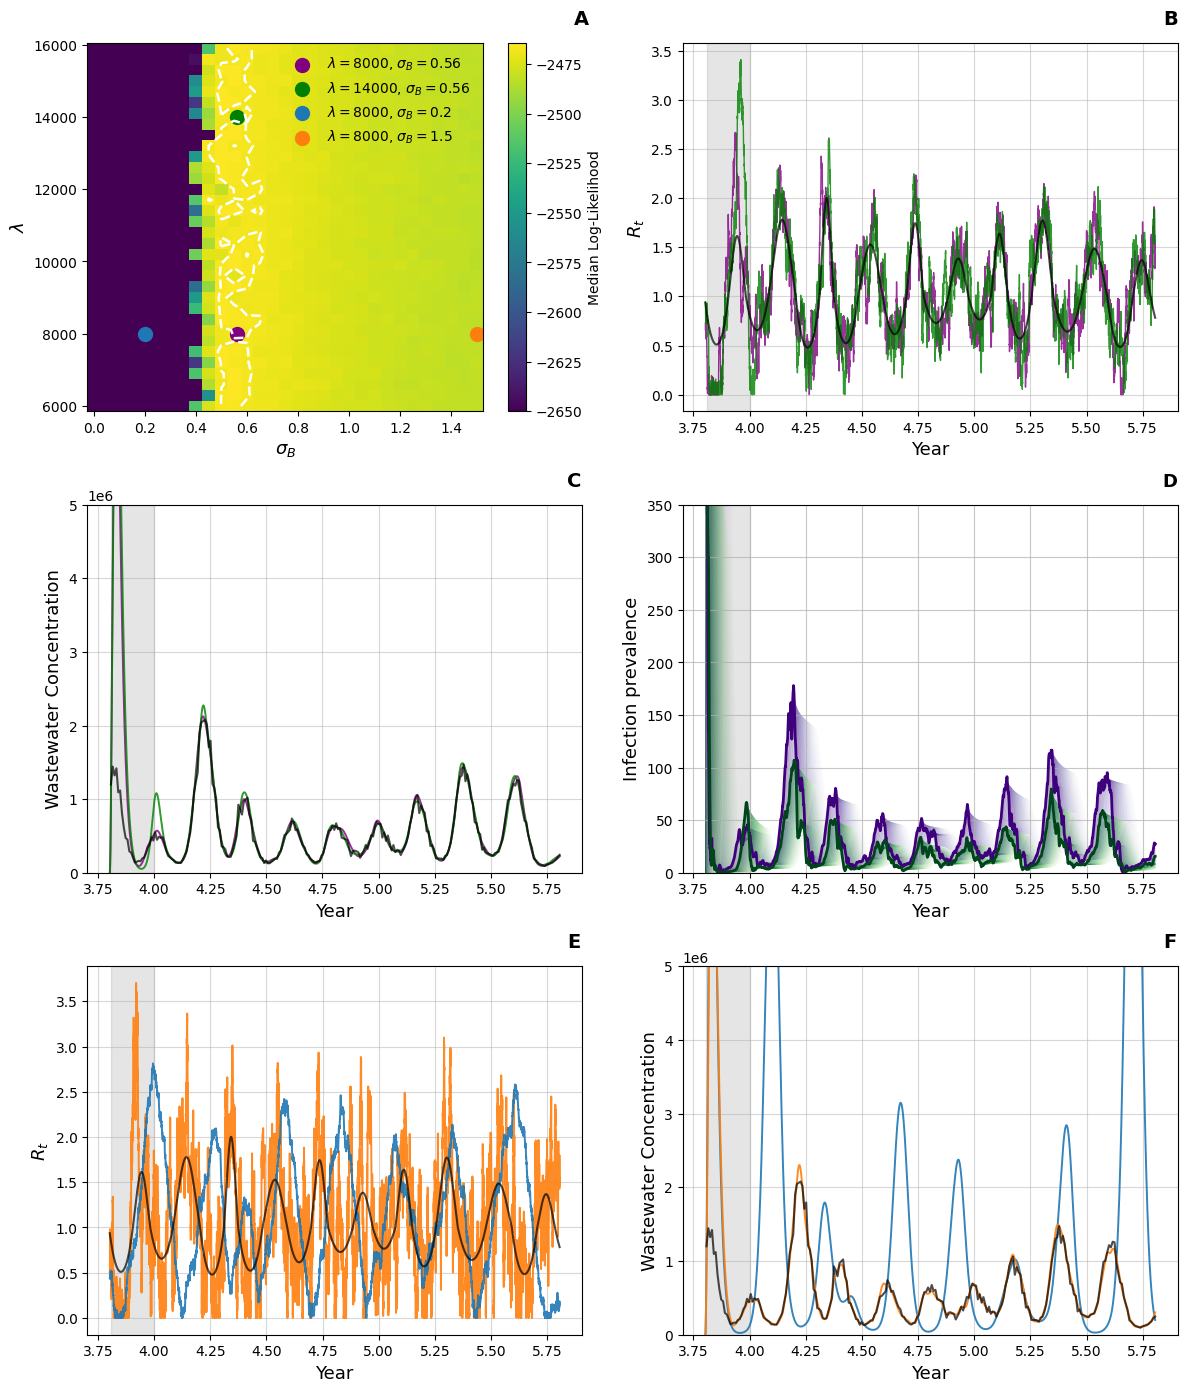

In [25]:
color_map = {(8000, 0.56): 'purple',   
             (14000, 0.56): 'green',
             (8000, 0.2):'tab:blue', 
             (8000, 1.5):'tab:orange'}   

label_font = {'fontsize': 13}
fig, axs = plt.subplots(3, 2, figsize=(12, 14))

# ========= Panel A – mean log‑likelihood heat‑map (λww vs σRe) =========
ax = axs[0, 0]

SigmaGrid, LambdaGrid = np.meshgrid(sigma_Re_value, lambda_value)
heat = ax.pcolormesh(SigmaGrid, LambdaGrid, median_ll_array_ww_replot,
                     cmap="viridis", shading="auto")
plt.colorbar(heat, ax=ax, label="Median Log‑Likelihood")
Lmax         = median_ll_array_ww_replot.max()
threshold_95 = Lmax - 2.996
cs = ax.contour(SigmaGrid, LambdaGrid, median_ll_array_ww_replot,
                 levels=[threshold_95], colors="white", linestyles="--",
                 linewidths=1.8)

# Mark the MLE σRe with a vertical red dashed line
i_max, j_max = np.unravel_index(np.argmax(median_ll_array_ww_replot),
                                median_ll_array_ww_replot.shape)
mle_sigma = sigma_Re_value[j_max]
# ax.axvline(0.56, color="red", linestyle=":", linewidth=2,label=fr"$\sigma_{{B}} = 0.56$") # {mle_sigma:.3g}$")

# Highlight the (λww, σRe) combinations
for (lambd, sig), col in color_map.items():
    ax.scatter(sig, lambd, color=col, s=100, marker='o',
               label=fr"$\lambda={lambd}$, $\sigma_{{B}}={sig}$")

ax.set_xlabel(r"$\sigma_{B}$", **label_font)
ax.set_ylabel(r"$\lambda$", **label_font)
ax.text(1.23, 1.05, 'A', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0)


# ========= Panel B – reconstructed $R_t$ for the two parameter sets =========
ax = axs[0, 1]

for (lambd, sig), recon in recon_dict_ww.items():
    ax.plot(recon["t"]/365, recon["Re"],
            color=color_map[(lambd, sig)],
            alpha=0.8, linewidth=1.0,
            label=fr"$\lambda={lambd}$, $\sigma_{{B}}={sig}$")

# (Optional) overlay the ground‑truth R_t for your synthetic data
ax.plot(tvector[start:end]/365, Re_list[start:end],
        linestyle='-', color='black', alpha=0.7, label='True $R_t$')
ax.axvspan(1390/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("$R_t$", **label_font)
ax.grid(True, alpha=0.5)
# ax.legend(loc='upper right', framealpha=0)
ax.text(0.97, 1.05, 'B', transform=ax.transAxes,
        fontsize=14, fontweight='bold')


# ========= Panel C – reconstructed WW_concentration =========
ax = axs[1, 0]

for (lambd, sig), recon in recon_dict_ww.items():
    ax.plot(recon["t"]/365, recon["WW_concentration"],
            color=color_map[(lambd, sig)],
            linewidth=1.4, alpha=0.8,
            label=fr"$\lambda={lambd}$, $\sigma_{{B}}={sig}$")

ax.plot(ww_mock['date_w']/365, ww_mock['noisy_w_values'],
        linestyle='-', color='black', alpha=0.7, label="True Wastewater Concentration")
ax.axvspan(1390/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("Wastewater Concentration", **label_font)
ax.set_ylim(0, 5e6)
ax.text(0.97, 1.05, 'C', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.5)
# ax.legend(loc='upper right', framealpha=0)



# -------------------------------------------------------------
# Panel D – prevalence: grayscale vs purple-white (wastewater)
# -------------------------------------------------------------
ax = axs[1, 1]

# Two (λww, σRe) sets to compare
combos = [(8000, 0.56),    # → grayscale
          (14000, 0.56)]    # → purple-white

k               = next(iter(recon_dict_ww.values()))['I_record'].shape[1]
colors_purple   = [plt.cm.Purples_r(i/(k-1)) for i in range(k)]   # purple → white
colors_green    = [plt.cm.Greens_r(i/(k-1))  for i in range(k)]   # green  → white
combo_cmaps     = {combos[0]: colors_purple,   # first tuple  → purple ramp
                   combos[1]: colors_green}    # second tuple → green  ramp
handles, labels = [], []    
for (lambd, sig) in combos:
    recon   = recon_dict_ww[(lambd, sig)]
    I_rec   = np.asarray(recon["I_record"])
    t_year  = recon["t"] / 365
    colors  = combo_cmaps[(lambd, sig)]

    # --- light ribbons for every compartment -----------------
    alpha_body = 0.45
    for i in reversed(range(k)):                               # darkest on top
        ax.plot(t_year, I_rec[:, i],
                color=colors[i],
                linewidth=0.4, alpha=alpha_body, zorder=1)

    # --- bold outline for the first compartment --------------
    first_compartment = I_rec[:, 0]
    outline_color     = colors[0]                              # darkest shade
    h, = ax.plot(t_year, first_compartment,
                 color=outline_color,
                 linewidth=2.0, zorder=2)
    handles.append(h)
    labels.append(fr"$\lambda={lambd}$, $\sigma_{{B}}={sig}$")

# ---- cosmetics ---------------------------------------------------------
ax.axvspan(1390/365, 1460/365, color='grey', alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("Infection prevalence", **label_font)
ax.text(0.97, 1.05, 'D', transform=ax.transAxes,
        **label_font, fontweight='bold')      # consistent tag style
ax.grid(True, alpha=0.7)
ax.set_ylim(0, 350)

# ax.legend(handles, labels, loc="upper right", fontsize=9, frameon=False)


# ========= Panel E – reconstructed Rt (sigma_B = 0.2 and 1.5) =========
ax = axs[2, 0]

for sig, col in [(1.5, "tab:orange"),(0.2, "tab:blue")]:
    recon = recon_dict_ww_EF[sig]
    ax.plot(recon["t"]/365, recon["Re"],
            color=col, alpha=0.9, linewidth=1.4,
            label=fr"$\lambda=8000,\ \sigma_B={sig}$")

ax.plot(tvector[start:end]/365, Re_list[start:end],
        color="black", alpha=0.7, label="True $R_t$")

ax.axvspan(1390/365, 1460/365, color="grey", alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("$R_t$", **label_font)
ax.grid(True, alpha=0.5)
ax.text(0.97, 1.05, "E", transform=ax.transAxes,
        fontsize=14, fontweight="bold")
# ax.legend(frameon=False)

# ========= Panel F – reconstructed wastewater concentration (sigma_B = 0.2 and 1.5) =========
ax = axs[2, 1]

for sig, col in [(0.2, "tab:blue"), (1.5, "tab:orange")]:
    recon = recon_dict_ww_EF[sig]
    ax.plot(recon["t"]/365, recon["WW_concentration"],
            color=col, alpha=0.9, linewidth=1.4,
            label=fr"$\lambda=8000,\ \sigma_B={sig}$")

# True wastewater concentration
ax.plot(ww_mock['date_w']/365, ww_mock['noisy_w_values'],
        linestyle='-', color='black', alpha=0.7,
        label="True Wastewater Concentration")

ax.axvspan(1390/365, 1460/365, color="grey", alpha=0.2)
ax.set_xlabel("Year", **label_font)
ax.set_ylabel("Wastewater Concentration", **label_font)
ax.set_ylim(0, 5e6)   # keep consistent with Panel C if you want
ax.grid(True, alpha=0.5)
ax.text(0.97, 1.05, "F", transform=ax.transAxes,
        fontsize=14, fontweight="bold")
# ax.legend(frameon=False)



plt.tight_layout()
plt.show()

### Figure 6: Mock case and wastewater datasets

In [8]:
epiparams = {
    "n" : 40, # Number of compartments
    "sigma_Re": 0.6,  # Initial standard deviation for Brownian motion
    "lambda_ww": 5000,  # Shedding load scaling constant
    "delta_ww":0.5, # Decay rate of viral load in wastewater
    "cv_ww": 0.1, # CV in wastewater 
    "k_overdispersion_case" : 10, # Overdispersion parameter for weekly incidence 
    "nu": 1/40,  # Transition rate 1 per day
    "dt": dt_real,  # Time step
    "time_start_day": 1388,  # Start day
    "time_end_day": 2119,  # End day
    "tList": tvector[start:end],  # Time steps
    "rho": 0.1 # Reporting rate (fraction of actual infections reported)
}

In [ ]:
n_repl    = 10              
logL_all_both  = np.empty((len(lambda_value), len(rho_value), n_repl))
mean_ll_array_both = np.empty((len(lambda_value), len(rho_value)))  

for i, lambd in enumerate(lambda_value):
    epiparams["lambda_ww"] = lambd
    for j, rho in enumerate(rho_value):
        epiparams["rho"] = rho
        for r in range(n_repl):
            theta_logL, recon = get_logL_Joint_prior(case_mock, ww_mock, n_particles, epiparams, burnin_point=1460)
            logL_all_both[i, j, r] = theta_logL     
        mean_ll_array_both[i, j] = logL_all_both[i, j].mean()

#np.save("logL_all_both.npy", logL_all_both)


In [9]:
logL_all_both = np.load("mock_results/logL_all_both.npy")
lambda_value = [2000, 3000, 4000, 5000, 6000, 7000, 9000, 2500, 3500, 4500, 5500, 6500, 7500, 9500, 10500, 12500, 14500, 16500, 18500] 
rho_value = [0.10, 0.14, 0.18, 0.22, 0.26, 0.30, 0.34, 0.38, 0.42, 0.46, 0.50, 0.54, 0.58, 0.62, 0.66, 0.70, 0.74, 0.78, 0.82, 0.86, 0.90, 0.94, 0.95]
median_matrix = util.analyze_median(logL_all_both, lambda_value, rho_value, n_repl=10)
mean_ll_array_both_replot = median_matrix.copy()
mean_ll_array_both_replot[mean_ll_array_both_replot < -2950] = -2950

In [10]:
recon_dict_both = {}
combinations = [
    (7500, 0.14),  # combination 1
    (18500, 0.34)   # combination 2
]

for (this_lambda, this_rho) in combinations:
    epiparams["lambda_ww"] = this_lambda
    epiparams["rho"] = this_rho
    theta_logL, recon = get_logL_Joint_prior(case_empt, ww_mock, n_particles, epiparams)
    recon_dict_both[(this_lambda, this_rho)] = recon

/var/folders/v6/xf9_4qmx6773k7fg_d6nrj1r0000gn/T/ipykernel_81901/3575228986.py:27: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = axA.pcolormesh(
/var/folders/v6/xf9_4qmx6773k7fg_d6nrj1r0000gn/T/ipykernel_81901/3575228986.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


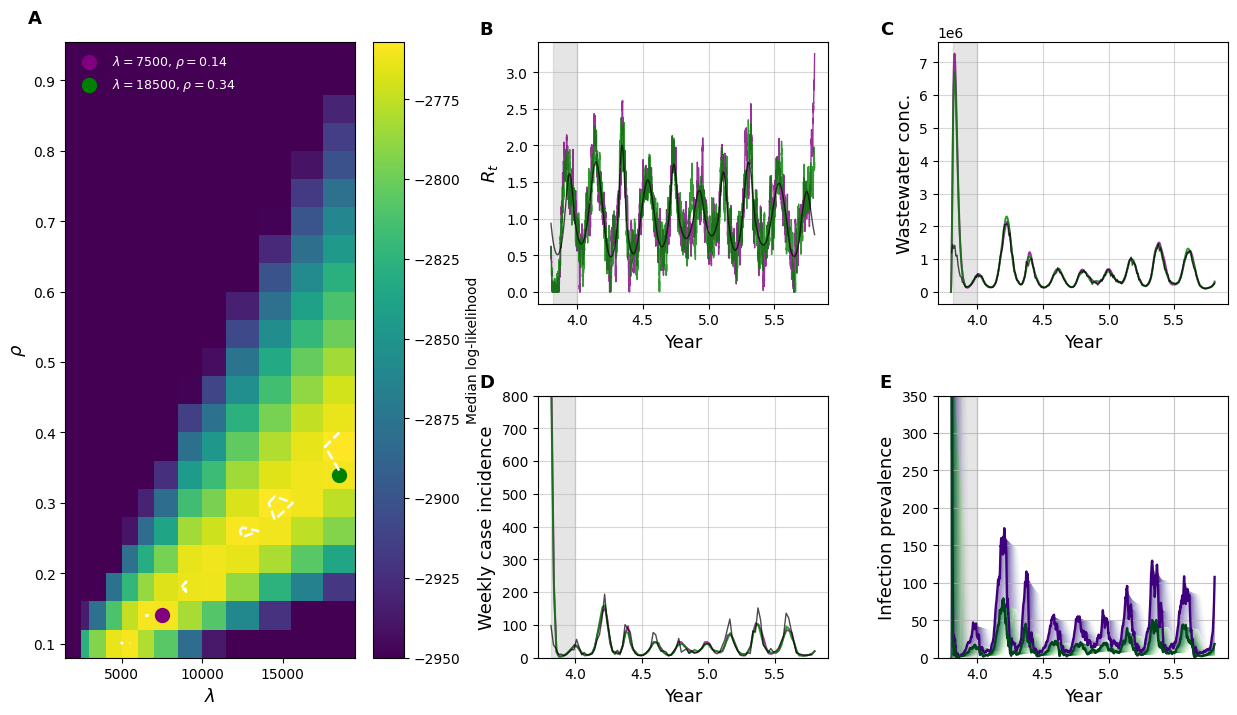

In [14]:
color_map = {(7500, 0.14): 'purple',
             (18500, 0.34): 'green'} 


RhoGrid, LambdaGrid = np.meshgrid(rho_value, lambda_value)        # NEW
Lmax         = mean_ll_array_both_replot.max()                          
i_max, j_max = np.unravel_index(np.argmax(mean_ll_array_both_replot),
                                mean_ll_array_both_replot.shape)
mle_lambda   = lambda_value[i_max]
mle_rho      = rho_value[j_max]

fig = plt.figure(figsize=(15, 8))
gs  = fig.add_gridspec(2, 3, width_ratios=[1.25, 1, 1],
                       hspace=.35, wspace=.35)

axA = fig.add_subplot(gs[:, 0])   # spans both rows
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])
axD = fig.add_subplot(gs[1, 1])
axE = fig.add_subplot(gs[1, 2])

label_font = {'fontsize': 13}

# ---------------------------------------------------------------
# PANEL A – mean log-likelihood over (λww, ρ)  [axes flipped]
# ---------------------------------------------------------------
mesh = axA.pcolormesh(
    LambdaGrid, RhoGrid, mean_ll_array_both_replot,
    cmap="viridis",
    shading="nearest"   # aligns cells exactly on your grid
)
plt.colorbar(mesh, ax=axA, label="Median log-likelihood")

Lmax         = mean_ll_array_both_replot.max()
threshold = Lmax - 2.996

for (lambd, rho), col in color_map.items():
    axA.scatter(
        lambd, rho,        # x = λww, y = ρ
        color=col, s=100, marker='o',
        label=fr"$\lambda={lambd}$, $\rho={rho}$"
    )

cs = axA.contour(
    LambdaGrid, RhoGrid, mean_ll_array_both_replot,
    levels=[threshold],
    colors="white",
    linestyles="--",
    linewidths=1.8
)

axA.set_xlabel(r"$\lambda$", **label_font)
axA.set_ylabel(r"$\rho$", **label_font)
axA.text(-0.13, 1.03, 'A', transform=axA.transAxes,
         **label_font, fontweight='bold')
leg = axA.legend(loc="upper left", fontsize=9, framealpha=0)
for text in leg.get_texts():
    text.set_color("white")



# ---------------------------------------------------------------
# PANEL B – reconstructed Rₜ  -----------------------------------
# ---------------------------------------------------------------
for (lambd, rho), recon in recon_dict_both.items():
    axB.plot(recon["t"]/365, recon["Re"],
             color=color_map[(lambd, rho)],
             lw=1.0, alpha=.8,
             label=fr"$\lambda={lambd}$, $\rho=={rho}$")
axB.plot(tvector[start:end]/365, Re_list[start:end],
         color="black", lw=1, alpha=.7, label="True $R_t$")
axB.axvspan(1394/365, 1460/365, color='grey', alpha=0.2)

axB.set_xlabel("Year", **label_font)
axB.set_ylabel(r"$R_t$", **label_font)
axB.grid(alpha=.5)
axB.text(-0.20, 1.03, 'B', transform=axB.transAxes,
         **label_font, fontweight='bold')
#axB.legend(loc="upper right", framealpha=0)

# ---------------------------------------------------------------
# PANEL C – reconstructed wastewater concentration --------------
# ---------------------------------------------------------------
for (lambd, rho), recon in recon_dict_both.items():
    axC.plot(recon["t"]/365, recon["WW_concentration"],
             color=color_map[(lambd, rho)],
             lw=1.4, alpha=.8,
             label=fr"$\lambda={lambd}$, $\rho=={rho}$")
axC.plot(ww_mock['date_w']/365, ww_mock['noisy_w_values'],
         color="black", lw=1, alpha=.7, label="True Wastewater Concentration")
axC.axvspan(1394/365, 1460/365, color='grey', alpha=0.2)

axC.set_xlabel("Year", **label_font)
axC.set_ylabel("Wastewater conc.", **label_font)
axC.grid(alpha=.5)
axC.text(-0.20, 1.03, 'C', transform=axC.transAxes,
         **label_font, fontweight='bold')
#axC.legend(loc="upper right", framealpha=0)

# ---------------------------------------------------------------
# PANEL D – weekly incidence  -----------------------------------
# ---------------------------------------------------------------
for (lambd, rho), recon in recon_dict_both.items():
    axD.plot(weekly_time/365, recon["w_incidence"],
             color=color_map[(lambd, rho)],
             lw=1.4, alpha=.8,
             label=fr"$\lambda={lambd}$, $\rho=={rho}$")
axD.plot(case_mock['date_c']/365, case_mock['noisy_c_values'],
         color="black", lw=1, alpha=.7, label="True weekly inc.")
axD.axvspan(1394/365, 1460/365, color='grey', alpha=0.2)

axD.set_xlabel("Year", **label_font)
axD.set_ylabel("Weekly case incidence", **label_font)
axD.set_ylim(0, 800)
axD.grid(alpha=.5)
axD.text(-0.20, 1.03, 'D', transform=axD.transAxes,
         **label_font, fontweight='bold')
#axD.legend(loc="upper right", framealpha=0)




# -------------------------------------------------------------
# Panel E – prevalence: grayscale vs purple-white (wastewater)
# -------------------------------------------------------------

handles, labels = [], []      

# Two (λww, σRe) sets to compare
combos = [(7500, 0.14),    # → grayscale
          (18500, 0.34)]    # → purple-white

k               = next(iter(recon_dict_both.values()))['I_record'].shape[1]
colors_purple   = [plt.cm.Purples_r(i/(k-1)) for i in range(k)]   # purple → white
colors_green    = [plt.cm.Greens_r(i/(k-1))  for i in range(k)]   # green  → white
combo_cmaps     = {combos[0]: colors_purple,   # first tuple  → purple ramp
                   combos[1]: colors_green}    # second tuple → green  ramp

for (lambd, rho) in combos:
    recon   = recon_dict_both[(lambd, rho)]
    I_rec   = np.asarray(recon["I_record"])
    t_year  = recon["t"] / 365
    colors  = combo_cmaps[(lambd, rho)]

    # --- light ribbons for every compartment -----------------
    alpha_body = 0.45
    for i in reversed(range(k)):                               # darkest on top
        axE.plot(t_year, I_rec[:, i],
                color=colors[i],
                linewidth=0.4, alpha=alpha_body, zorder=1)

    # --- bold outline for the first compartment --------------
    first_compartment = I_rec[:, 0]
    outline_color     = colors[0]                              # darkest shade
    h, = axE.plot(t_year, first_compartment,
                 color=outline_color,
                 linewidth=1.7, zorder=2)
    handles.append(h)
    labels.append(fr"$\lambda={lambd}$, $\rho={rho}$")

axE.axvspan(1394/365, 1460/365, color='grey', alpha=0.2)

# ---- cosmetics ---------------------------------------------------------
axE.set_xlabel("Year", **label_font)
axE.set_ylabel("Infection prevalence", **label_font)
axE.text(-0.2, 1.03, 'E', transform=axE.transAxes,
        **label_font, fontweight='bold')      # consistent tag style
axE.grid(True, alpha=0.7)
axE.set_ylim(0, 350)

#axE.legend(handles, labels, loc="upper right", fontsize=9, frameon=False)


plt.tight_layout()
plt.show()
